In [3]:
# ==========================================================
# Loan Approval Prediction
# Feature Engineering
# ==========================================================

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings("ignore")


In [4]:
loan_df = pd.read_csv(
"/Users/lingareddydhanushkumar/Desktop/Codex/ML/01_Loan_Approval_Prediction/data/processed/loan_clean.csv"
)

loan_df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0.0,Graduate,No,5849,0.0,127.0,360.0,1.0,Urban,Y
1,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
loan_df["TotalIncome"] = (
    loan_df["ApplicantIncome"] +
    loan_df["CoapplicantIncome"]
)

loan_df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
0,Male,No,0.0,Graduate,No,5849,0.0,127.0,360.0,1.0,Urban,Y,5849.0
1,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0
2,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0
3,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0
4,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0


In [9]:
loan_df["Income_Loan_Ratio"] = (
    loan_df["TotalIncome"] /
    loan_df["LoanAmount"]
)

In [11]:
loan_df["EMI"] = (
    loan_df["LoanAmount"] /
    loan_df["Loan_Amount_Term"]
)

In [13]:
loan_df["LoanIncomeRatio"] = (
    loan_df["LoanAmount"] /
    loan_df["TotalIncome"]
)

In [15]:
loan_df["ApplicantIncome_Log"] = np.log1p(
    loan_df["ApplicantIncome"]
)

In [17]:
loan_df["TotalIncome_Log"] = np.log1p(
    loan_df["TotalIncome"]
)

In [19]:
loan_df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,Income_Loan_Ratio,EMI,LoanIncomeRatio,ApplicantIncome_Log,TotalIncome_Log
0,Male,No,0.0,Graduate,No,5849,0.0,127.0,360.0,1.0,Urban,Y,5849.0,46.055118,0.352778,0.021713,8.674197,8.674197
1,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,47.585938,0.355556,0.021015,8.430327,8.714732
2,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,45.454545,0.183333,0.022000,8.006701,8.006701
3,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,41.175000,0.333333,0.024287,7.857094,8.505525
4,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,42.553191,0.391667,0.023500,8.699681,8.699681


In [21]:
cat_cols = loan_df.select_dtypes(
    include="object"
).columns

cat_cols

Index(['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area',
       'Loan_Status'],
      dtype='object')

In [23]:
le = LabelEncoder()

In [25]:
for col in cat_cols:

    loan_df[col] = le.fit_transform(
        loan_df[col]
    )

In [27]:
loan_df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,Income_Loan_Ratio,EMI,LoanIncomeRatio,ApplicantIncome_Log,TotalIncome_Log
0,1,0,0.0,0,0,5849,0.0,127.0,360.0,1.0,2,1,5849.0,46.055118,0.352778,0.021713,8.674197,8.674197
1,1,1,1.0,0,0,4583,1508.0,128.0,360.0,1.0,0,0,6091.0,47.585938,0.355556,0.021015,8.430327,8.714732
2,1,1,0.0,0,1,3000,0.0,66.0,360.0,1.0,2,1,3000.0,45.454545,0.183333,0.022000,8.006701,8.006701
3,1,1,0.0,1,0,2583,2358.0,120.0,360.0,1.0,2,1,4941.0,41.175000,0.333333,0.024287,7.857094,8.505525
4,1,0,0.0,0,0,6000,0.0,141.0,360.0,1.0,2,1,6000.0,42.553191,0.391667,0.023500,8.699681,8.699681


In [29]:
loan_df.corr()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,Income_Loan_Ratio,EMI,LoanIncomeRatio,ApplicantIncome_Log,TotalIncome_Log
Gender,1.000000,0.369612,0.172620,0.048478,-0.028663,0.057386,0.083080,0.103640,-0.082771,0.012708,-0.025794,0.021239,0.093012,-0.009199,0.058064,-0.111793,0.088834,0.170409
Married,0.369612,1.000000,0.344500,0.014369,-0.021441,0.042487,0.073830,0.144638,-0.101137,0.017964,0.009224,0.093183,0.074713,-0.046253,0.090352,-0.010764,0.018548,0.145260
Dependents,0.172620,0.344500,1.000000,0.054050,0.040957,0.084744,0.036101,0.131133,-0.103481,-0.034664,0.002034,0.009105,0.096248,-0.030184,0.085010,0.064485,0.091506,0.090596
Education,0.048478,0.014369,0.054050,1.000000,-0.015204,-0.139349,-0.065205,-0.167403,-0.075839,-0.067300,-0.061758,-0.081617,-0.161039,-0.091646,-0.073783,0.076875,-0.182296,-0.203330
Self_Employed,-0.028663,-0.021441,0.040957,-0.015204,1.000000,0.140406,0.020877,0.115923,-0.033055,0.034679,-0.023149,-0.005605,0.140981,0.087416,0.053084,-0.072090,0.154430,0.167842
ApplicantIncome,0.057386,0.042487,0.084744,-0.139349,0.140406,1.000000,-0.109235,0.524426,-0.036617,-0.033683,-0.023432,-0.025248,0.881652,0.424653,0.289733,-0.310198,0.786835,0.705329
CoapplicantIncome,0.083080,0.073830,0.036101,-0.065205,0.020877,-0.109235,1.000000,0.207458,-0.059922,0.014622,0.015155,-0.058194,0.372770,0.285582,0.142736,-0.208787,-0.229043,0.403573
LoanAmount,0.103640,0.144638,0.131133,-0.167403,0.115923,0.524426,0.207458,1.000000,0.046119,-0.010908,-0.057273,-0.050701,0.588045,-0.150528,0.472282,0.175198,0.539044,0.678714
Loan_Amount_Term,-0.082771,-0.101137,-0.103481,-0.075839,-0.033055,-0.036617,-0.059922,0.046119,1.000000,-0.001380,-0.069933,-0.018931,-0.062630,-0.099878,-0.503342,0.157419,-0.020138,-0.045495
Credit_History,0.012708,0.017964,-0.034664,-0.067300,0.034679,-0.033683,0.014622,-0.010908,-0.001380,1.000000,-0.004182,0.535638,-0.024502,0.049625,0.009388,-0.033855,0.002800,0.012302


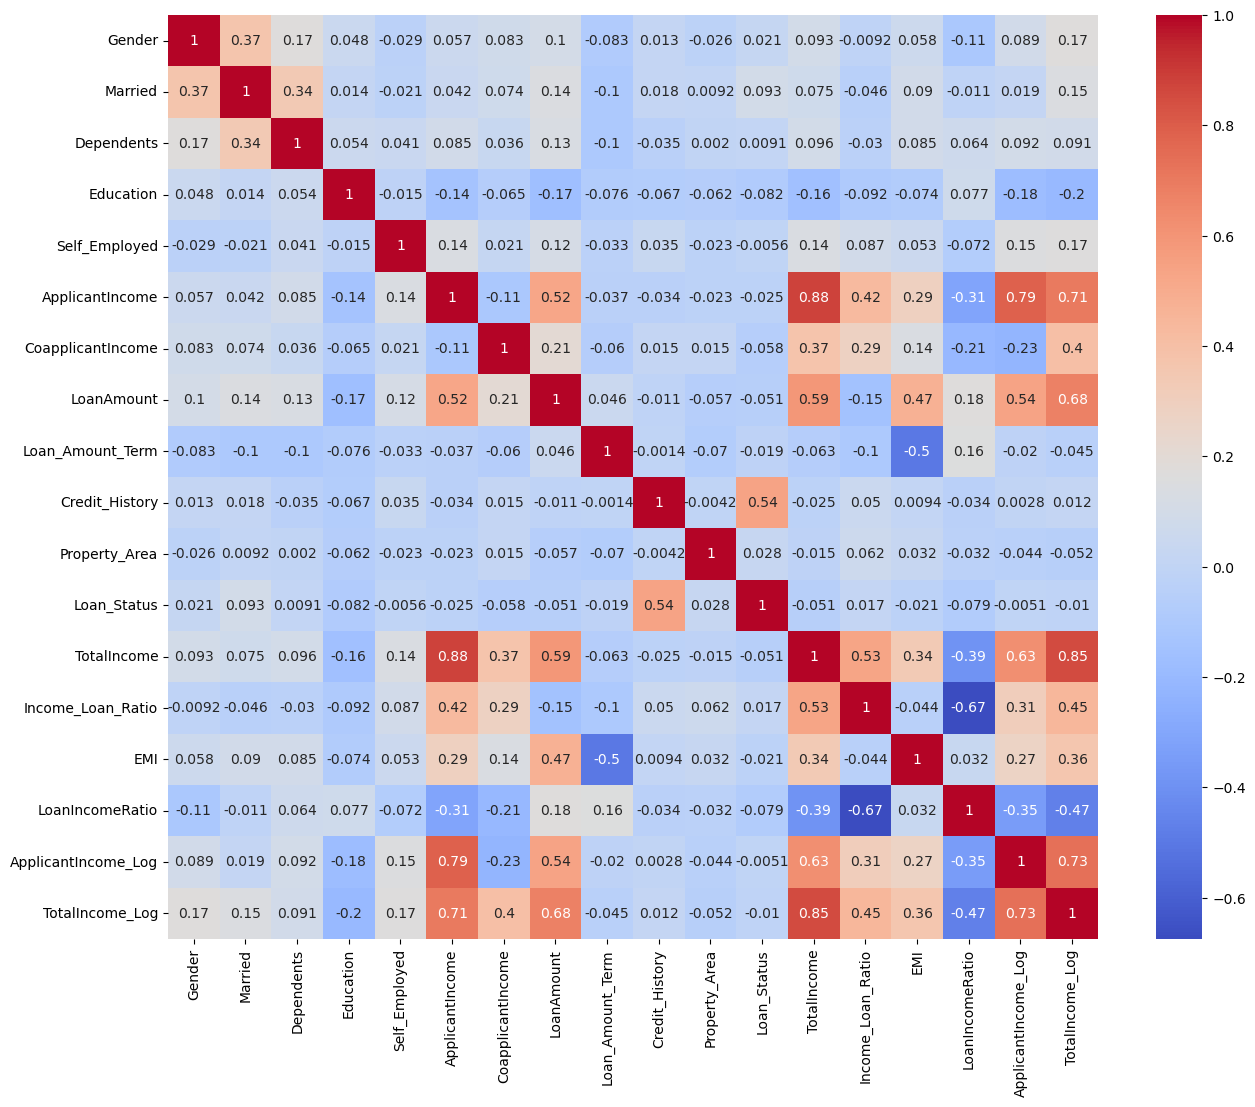

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,12))

sns.heatmap(
    loan_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [32]:
X = loan_df.drop("Loan_Status", axis=1)

y = loan_df["Loan_Status"]

In [35]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X,y)

RandomForestClassifier(random_state=42)

In [36]:
importance = pd.DataFrame({

"Feature":X.columns,

"Importance":rf.feature_importances_

})

importance = importance.sort_values(

"Importance",

ascending=False

)

importance

,Feature,Importance
9,Credit_History,0.255276
14,LoanIncomeRatio,0.082766
12,Income_Loan_Ratio,0.079392
16,TotalIncome_Log,0.076940
15,ApplicantIncome_Log,0.075917
5,ApplicantIncome,0.075274
11,TotalIncome,0.074614
13,EMI,0.064537
7,LoanAmount,0.058668
6,CoapplicantIncome,0.045251


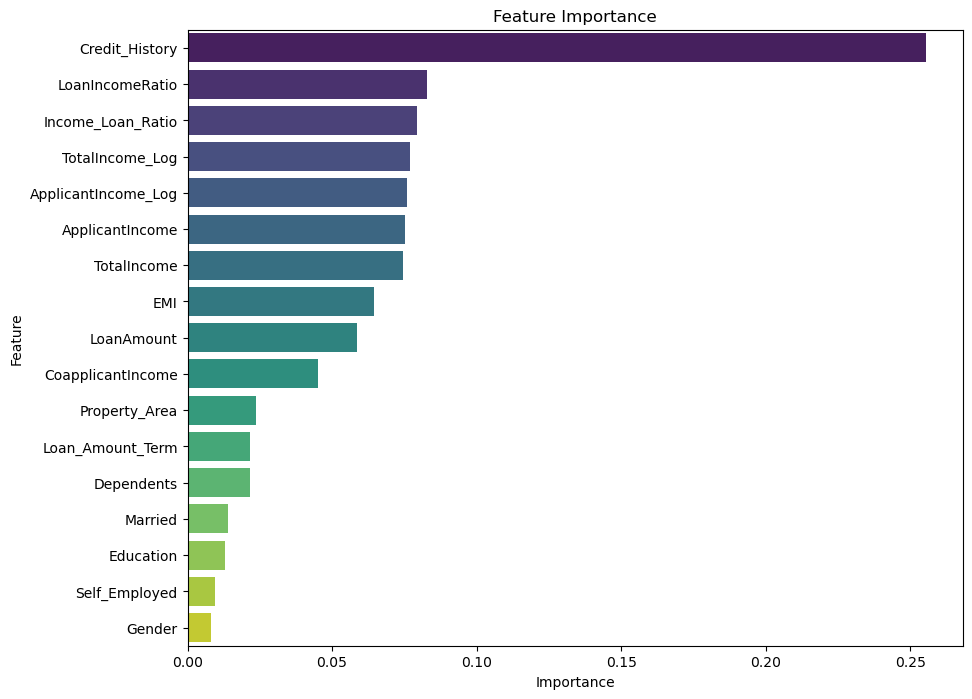

In [39]:
plt.figure(figsize=(10,8))

sns.barplot(

x="Importance",

y="Feature",

data=importance,

palette="viridis"

)

plt.title("Feature Importance")

plt.show()

In [41]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(
    X,
    y,
    random_state=42
)

mi = pd.Series(
    mi,
    index=X.columns
)

mi = mi.sort_values(
    ascending=False
)

mi

Credit_History         0.167294
Education              0.028826
Loan_Amount_Term       0.021245
Property_Area          0.019187
Married                0.008380
ApplicantIncome        0.006049
ApplicantIncome_Log    0.002955
TotalIncome            0.000000
LoanIncomeRatio        0.000000
EMI                    0.000000
Income_Loan_Ratio      0.000000
Gender                 0.000000
LoanAmount             0.000000
CoapplicantIncome      0.000000
Self_Employed          0.000000
Dependents             0.000000
TotalIncome_Log        0.000000
dtype: float64

In [43]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(
    X,
    y,
    random_state=42
)

mi = pd.Series(
    mi,
    index=X.columns
)

mi = mi.sort_values(
    ascending=False
)

mi

Credit_History         0.167294
Education              0.028826
Loan_Amount_Term       0.021245
Property_Area          0.019187
Married                0.008380
ApplicantIncome        0.006049
ApplicantIncome_Log    0.002955
TotalIncome            0.000000
LoanIncomeRatio        0.000000
EMI                    0.000000
Income_Loan_Ratio      0.000000
Gender                 0.000000
LoanAmount             0.000000
CoapplicantIncome      0.000000
Self_Employed          0.000000
Dependents             0.000000
TotalIncome_Log        0.000000
dtype: float64

In [45]:
num_cols = [

"ApplicantIncome",

"CoapplicantIncome",

"LoanAmount",

"Loan_Amount_Term",

"TotalIncome",

"Income_Loan_Ratio",

"EMI",

"LoanIncomeRatio",

"ApplicantIncome_Log",

"LoanAmount_Log",

"TotalIncome_Log"

]

In [47]:
print(loan_df.columns.tolist())

['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status', 'TotalIncome', 'Income_Loan_Ratio', 'EMI', 'LoanIncomeRatio', 'ApplicantIncome_Log', 'TotalIncome_Log']


In [50]:
loan_df["TotalIncome"] = (
    loan_df["ApplicantIncome"] +
    loan_df["CoapplicantIncome"]
)

loan_df["Income_Loan_Ratio"] = (
    loan_df["TotalIncome"] /
    loan_df["LoanAmount"]
)

loan_df["EMI"] = (
    loan_df["LoanAmount"] /
    loan_df["Loan_Amount_Term"]
)

loan_df["LoanIncomeRatio"] = (
    loan_df["LoanAmount"] /
    loan_df["TotalIncome"]
)

loan_df["ApplicantIncome_Log"] = np.log1p(
    loan_df["ApplicantIncome"]
)

loan_df["LoanAmount_Log"] = np.log1p(
    loan_df["LoanAmount"]
)

loan_df["TotalIncome_Log"] = np.log1p(
    loan_df["TotalIncome"]
)

In [52]:
loan_df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'TotalIncome', 'Income_Loan_Ratio', 'EMI', 'LoanIncomeRatio',
       'ApplicantIncome_Log', 'TotalIncome_Log', 'LoanAmount_Log'],
      dtype='object')

In [54]:
missing_cols = [col for col in num_cols if col not in loan_df.columns]

print("Missing Columns:", missing_cols)

Missing Columns: []


In [56]:
missing_cols = [col for col in num_cols if col not in loan_df.columns]
print(missing_cols)

[]


In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

loan_df[num_cols] = scaler.fit_transform(loan_df[num_cols])

loan_df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,Income_Loan_Ratio,EMI,LoanIncomeRatio,ApplicantIncome_Log,TotalIncome_Log,LoanAmount_Log
0,1,0,0.0,0,0,0.095951,-0.552892,-0.213425,0.274031,1.0,2,1,-0.172910,-0.135268,-0.229622,-0.249273,0.539391,0.022901,-0.013951
1,1,1,1.0,0,0,-0.122234,-0.041852,-0.201115,0.274031,1.0,0,0,-0.133976,-0.094839,-0.224180,-0.329632,0.152174,0.098340,0.001994
2,1,1,0.0,0,1,-0.395052,-0.552892,-0.964324,0.274031,1.0,2,1,-0.631266,-0.151129,-0.561597,-0.216268,-0.520462,-1.219365,-1.340341
3,1,1,0.0,1,0,-0.466919,0.246201,-0.299594,0.274031,1.0,2,1,-0.318992,-0.264151,-0.267718,0.046793,-0.758008,-0.291011,-0.129186
4,1,0,0.0,0,0,0.121975,-0.552892,-0.041088,0.274031,1.0,2,1,-0.148616,-0.227753,-0.153431,-0.043700,0.579856,0.070330,0.198728


In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

loan_df[num_cols] = scaler.fit_transform(loan_df[num_cols])

print("Scaling completed successfully!")

Scaling completed successfully!


In [62]:
loan_df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'TotalIncome', 'Income_Loan_Ratio', 'EMI', 'LoanIncomeRatio',
       'ApplicantIncome_Log', 'TotalIncome_Log', 'LoanAmount_Log'],
      dtype='object')

In [67]:
loan_df.to_csv(
    "/Users/lingareddydhanushkumar/Desktop/Codex/ML/01_Loan_Approval_Prediction/data/processed/loan_feature_engineered.csv",
    index=False
)

print("Feature-engineered dataset saved successfully!")

Feature-engineered dataset saved successfully!


In [69]:
import os

folder = "/Users/lingareddydhanushkumar/Desktop/Codex/ML/01_Loan_Approval_Prediction/data/processed"

print(os.listdir(folder))

['loan_feature_engineered.csv', 'loan_clean.csv', 'LoanApprovalPrediction.csv']
